In [64]:
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [65]:
data_path = 'data/'
csv_files = glob.glob(data_path + 'pair_*.csv')
print("Found files:", csv_files)

Found files: ['data\\pair_1_2001_2005_to_2006_2010.csv', 'data\\pair_2_2006_2010_to_2011_2015.csv', 'data\\pair_3_2011_2015_to_2016_2020.csv', 'data\\pair_4_2016_2020_to_2021_2023.csv']


In [66]:
df_list = []
for i, file in enumerate(csv_files):
    temp = pd.read_csv(file)
    period_name = file.split('_to_')[0].replace(data_path, '')
    temp['period'] = period_name
    df_list.append(temp)

In [67]:
df = pd.concat(df_list, ignore_index=True)
print(f"Total samples: {len(df)}")

Total samples: 1793


### Data Cleaning

In [68]:
df = df.drop(columns=['.geo', 'system:index'], errors='ignore')
# Check for missing values
print("Missing values:\n", df.isnull().sum())
# Check duplicates
print(f"Duplicates: {df.duplicated().sum()}")
# If duplicates exist, drop them
df = df.drop_duplicates()

Missing values:
 loss_label          0
past_loss           0
rainfall_anomaly    0
rainfall_total      0
spi                 0
treecover2000       0
period              0
dtype: int64
Duplicates: 3


# EDA

### Class Balance

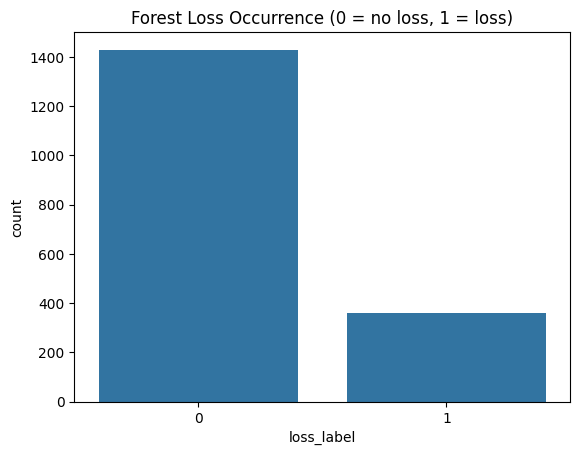

In [69]:
sns.countplot(x='loss_label', data=df)
plt.title('Forest Loss Occurrence (0 = no loss, 1 = loss)')
plt.show()

In [70]:
print(df['loss_label'].value_counts(normalize=True))

loss_label
0    0.798324
1    0.201676
Name: proportion, dtype: float64


### Feature Distributions

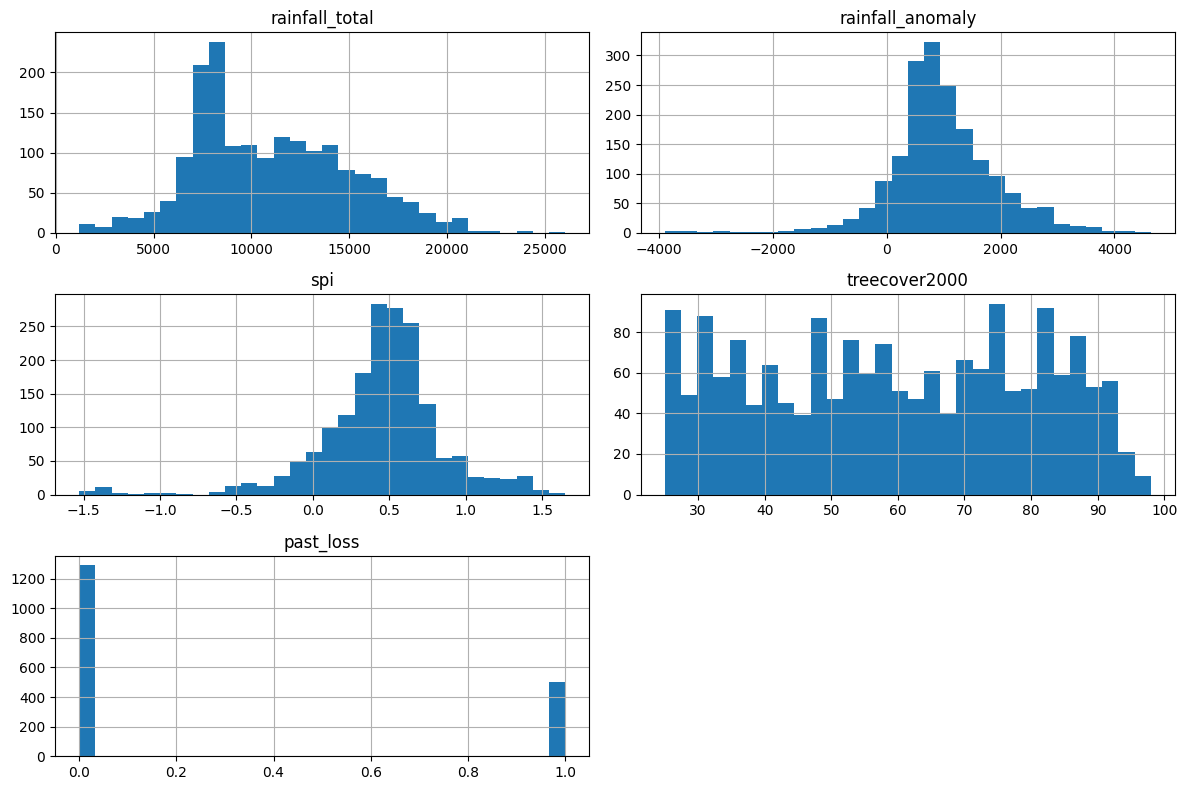

In [71]:
numerical_features = ['rainfall_total', 'rainfall_anomaly', 'spi', 'treecover2000', 'past_loss']
df[numerical_features].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

### Correlation Matrix

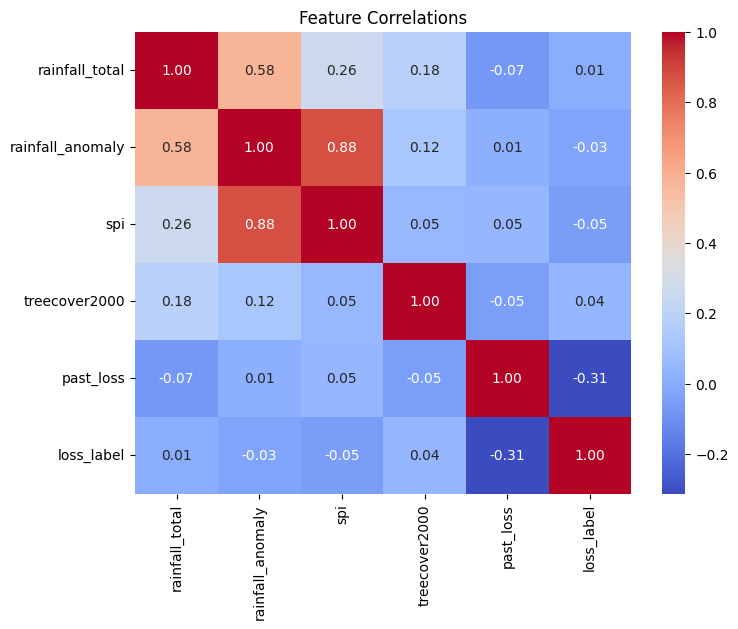

In [72]:
corr = df[numerical_features + ['loss_label']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlations')
plt.show()

### Boxplots by Class
See how features differ between loss and no‑loss pixels.

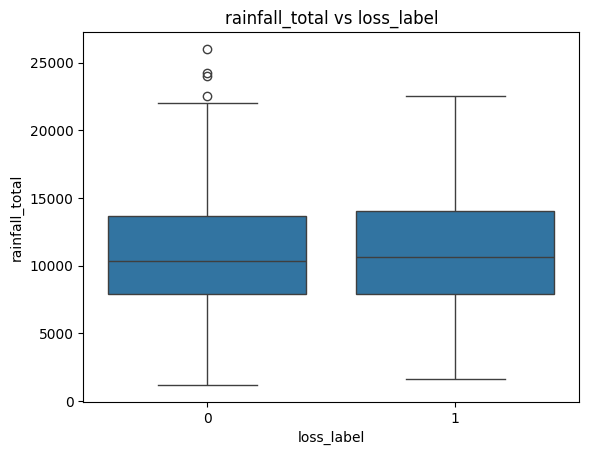

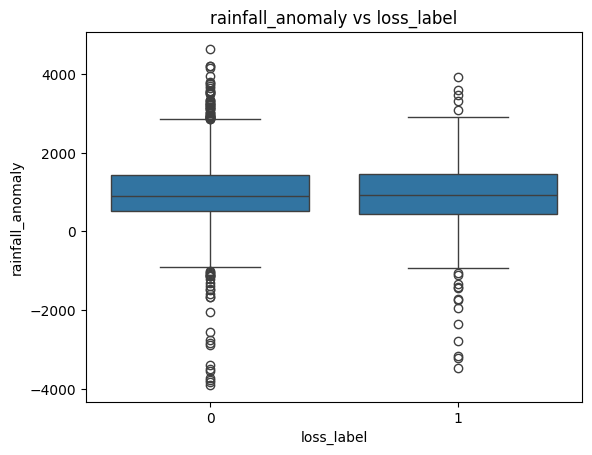

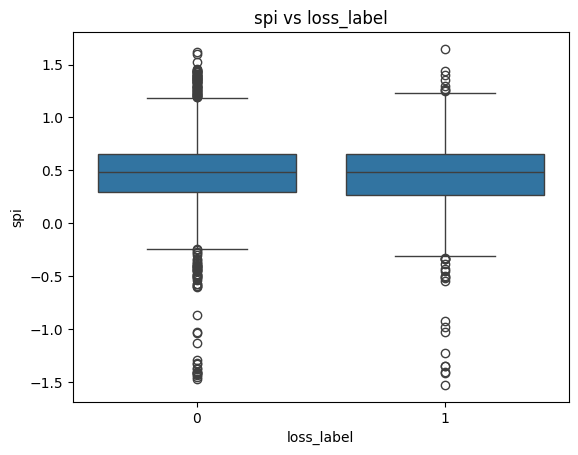

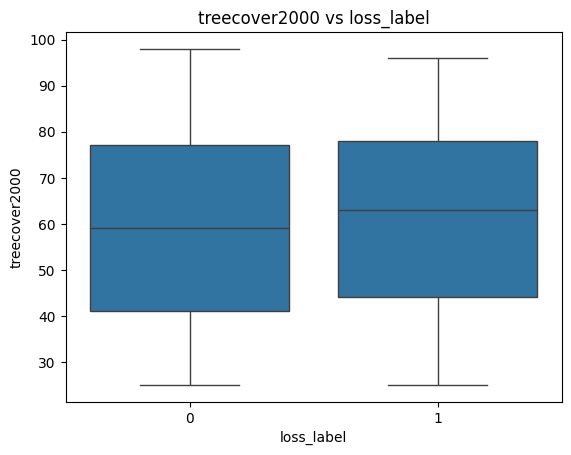

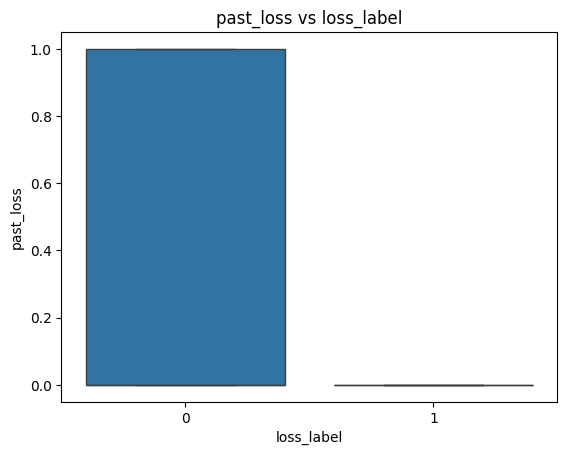

In [73]:
for feat in numerical_features:
    plt.figure()
    sns.boxplot(x='loss_label', y=feat, data=df)
    plt.title(f'{feat} vs loss_label')
    plt.show()

In [74]:
df.dtypes

loss_label            int64
past_loss             int64
rainfall_anomaly    float64
rainfall_total      float64
spi                 float64
treecover2000         int64
period               object
dtype: object

In [75]:
df['period'] = df['period'].str.replace(r'data\\pair_1_', '', regex=True)
df['period'] = df['period'].str.replace(r'data\\pair_2_', '', regex=True)
df['period'] = df['period'].str.replace(r'data\\pair_3_', '', regex=True)
df['period'] = df['period'].str.replace(r'data\\pair_4_', '', regex=True)

In [76]:
output_file = os.path.join("data/", 'forest_loss_training_data_clean.csv')
df.to_csv(output_file, index=False)
print(f"✅ Cleaned dataset saved to: {output_file}")

✅ Cleaned dataset saved to: data/forest_loss_training_data_clean.csv
